Импорт нужных библиотек

In [78]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed = 42

set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [79]:
data = pd.read_csv("S12-hw-dataset.csv")
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date').reset_index(drop=True)
data.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [80]:
date_min = data['date'].min()
date_max = data['date'].max()
print(f"Число наблюдений: {len(data)}")
print(f"Диапазон дат: {date_min} — {date_max}")
print(f"Продолжительность: {date_max - date_min}")
print("\nПропуски по колонкам:")
print(data.isnull().sum())
print("\nБазовая статистика target:")
print(data['target'].describe())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Продолжительность: 179 days 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64

Базовая статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


Временной ряд демонстрирует слабовыраженный возрастающий тренд, ярко выраженную суточную и недельную сезонность с более низким уровнем и амплитудой в выходные дни, наличие аномальных выбросов и явную нестационарность, проявляющуюся в изменении среднего значения и растущей дисперсии к концу периода

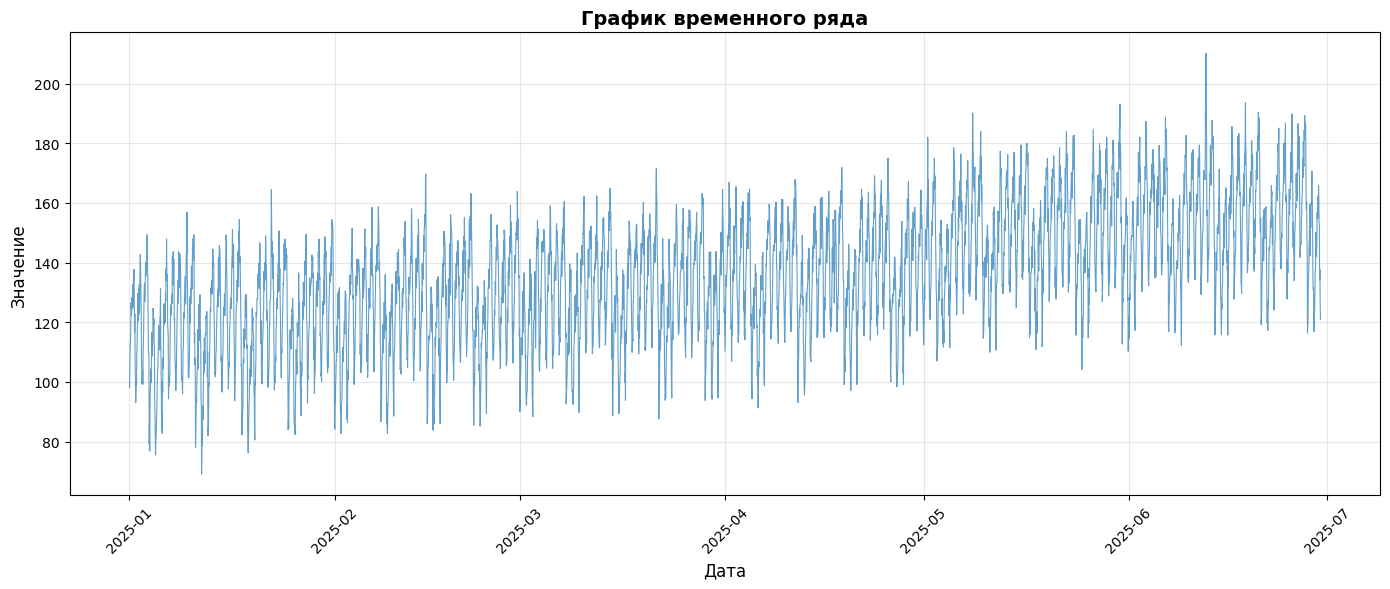

In [81]:
plt.figure(figsize=(14, 6))
plt.plot(data['date'], data['target'], linewidth=0.8, alpha=0.7)
plt.title('График временного ряда', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

n_total = len(data)
train_size = int(n_total * train_ratio)
val_size = int(n_total * val_ratio)
test_size = n_total - train_size - val_size

train_end_idx = train_size
val_end_idx = train_size + val_size
test_end_idx = n_total

train_end_date = data.iloc[train_end_idx - 1]['date']
val_start_date = data.iloc[train_end_idx]['date']
val_end_date = data.iloc[val_end_idx - 1]['date']
test_start_date = data.iloc[val_end_idx]['date']
test_end_date = data.iloc[test_end_idx - 1]['date']

In [83]:
train_data = data.iloc[:train_end_idx].copy()
val_data = data.iloc[train_end_idx:val_end_idx].copy()
test_data = data.iloc[val_end_idx:].copy()

print("Границы temporal split\n")

print(f"\nОбщий объем данных: {n_total} наблюдений")
print(f"\nРазмеры наборов:")
print(f"  Train:      {len(train_data):5d} записей ({len(train_data)/n_total*100:.1f}%)")
print(f"  Validation: {len(val_data):5d} записей ({len(val_data)/n_total*100:.1f}%)")
print(f"  Test:       {len(test_data):5d} записей ({len(test_data)/n_total*100:.1f}%)")

print(f"\nГраницы по времени:")
print(f"  Train:      {data['date'].min()} — {train_end_date}")
print(f"  Validation: {val_start_date} — {val_end_date}")
print(f"  Test:       {test_start_date} — {data['date'].max()}")

print(f"\nИндексные границы:")
print(f"  Train:      [0 : {train_end_idx}]")
print(f"  Validation: [{train_end_idx} : {val_end_idx}]")
print(f"  Test:       [{val_end_idx} : {test_end_idx}]")

Границы temporal split


Общий объем данных: 4320 наблюдений

Размеры наборов:
  Train:       3024 записей (70.0%)
  Validation:   648 записей (15.0%)
  Test:         648 записей (15.0%)

Границы по времени:
  Train:      2025-01-01 00:00:00 — 2025-05-06 23:00:00
  Validation: 2025-05-07 00:00:00 — 2025-06-02 23:00:00
  Test:       2025-06-03 00:00:00 — 2025-06-29 23:00:00

Индексные границы:
  Train:      [0 : 3024]
  Validation: [3024 : 3672]
  Test:       [3672 : 4320]


In [84]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли покрывают весь датасет
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)

    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df


train_df, val_df, test_df = temporal_split(data)

Random split перемешает данные, из-за чего нарушится хронология, а также модель может обучаться на данных из будущего

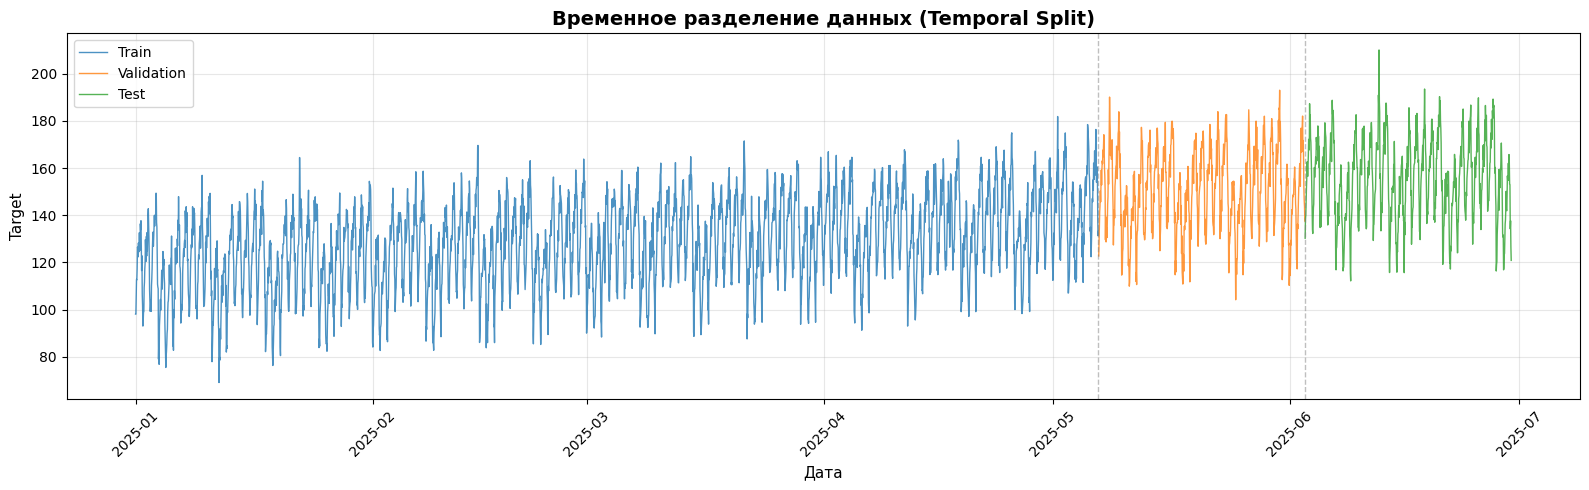

In [85]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train_df["date"], train_df["target"], label="Train", color='#1f77b4', linewidth=1, alpha=0.8)
ax.plot(val_df["date"], val_df["target"], label="Validation", color='#ff7f0e', linewidth=1, alpha=0.8)
ax.plot(test_df["date"], test_df["target"], label="Test", color='#2ca02c', linewidth=1, alpha=0.8)

# Вертикальные линии на границах разбиения
ax.axvline(x=train_df['date'].max(), color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=val_df['date'].max(), color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title("Временное разделение данных (Temporal Split)", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [86]:
def add_calendar_features(dataset: pd.DataFrame):
    """
    Добавляет календарные признаки из колонки 'date'
    """
    calendar = data.copy()

    calendar["hour"] = calendar["date"].dt.hour
    calendar["day_of_week"] = calendar["date"].dt.dayofweek  # 0=пн, 6=вс
    calendar["day_of_month"] = calendar["date"].dt.day
    calendar["month"] = calendar["date"].dt.month
    calendar["is_weekend"] = (calendar["day_of_week"] >= 5).astype(int)

    calendar["hour_sin"] = np.sin(2 * np.pi * calendar["hour"] / 24)
    calendar["hour_cos"] = np.cos(2 * np.pi * calendar["hour"] / 24)
    calendar["dow_sin"] = np.sin(2 * np.pi * calendar["day_of_week"] / 7)
    calendar["dow_cos"] = np.cos(2 * np.pi * calendar["day_of_week"] / 7)

    return calendar


def create_time_features(dataset: pd.DataFrame, value_column: str = "target") -> pd.DataFrame:
    """
    Создание лаговых и скользящих признаков для временного ряда.
    Все признаки строятся со сдвигом на 1 шаг для исключения утечки данных
    """
    calendar = dataset.copy()

    lag_periods = [1, 2, 3, 5, 7, 10, 14, 21, 28, 35, 42]
    for period in lag_periods:
        calendar[f"lag_{period}"] = calendar[value_column].shift(period)

    window_sizes = [3, 7, 14, 28]
    for window in window_sizes:
        shifted_series = calendar[value_column].shift(1)
        calendar[f"roll_mean_{window}"] = shifted_series.rolling(window).mean()
        calendar[f"roll_std_{window}"] = shifted_series.rolling(window).std()
        calendar[f"roll_max_{window}"] = shifted_series.rolling(window).max()
        calendar[f"roll_min_{window}"] = shifted_series.rolling(window).min()
        calendar[f"roll_range_{window}"] = calendar[f"roll_max_{window}"] - calendar[f"roll_min_{window}"]

    smoothing_factors = [0.3, 0.1]
    for factor in smoothing_factors:
        col_name = f"ewm_{int(factor * 10)}"
        calendar[col_name] = calendar[value_column].shift(1).ewm(alpha=factor).mean()

    calendar["diff_1"] = calendar[value_column].shift(1).diff(1)
    calendar["diff_7"] = calendar[value_column].shift(1).diff(7)
    calendar["diff_28"] = calendar[value_column].shift(1).diff(28)

    return calendar

features_data = add_calendar_features(data)
features_data = create_time_features(features_data)

features_data = features_data.dropna().reset_index(drop=True)
features_data.head()

,date,target,hour,day_of_week,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,lag_14,lag_21,lag_28,lag_35,lag_42,roll_mean_3,roll_std_3,roll_max_3,roll_min_3,roll_range_3,roll_mean_7,roll_std_7,roll_max_7,roll_min_7,roll_range_7,roll_mean_14,roll_std_14,roll_max_14,roll_min_14,roll_range_14,roll_mean_28,roll_std_28,roll_max_28,roll_min_28,roll_range_28,ewm_3,ewm_1,diff_1,diff_7,diff_28
0,2025-01-02 18:00:00,130.48,18,3,2,1,0,-1.000000,-1.836970e-16,0.433884,-0.900969,137.18,142.80,140.38,125.00,122.76,124.85,111.64,106.54,128.87,126.01,98.14,140.120000,2.819007,142.80,137.18,5.62,133.118571,7.534964,142.8,122.76,20.04,127.610714,8.992419,142.8,111.64,31.16,121.176429,14.390252,142.8,93.04,49.76,135.446374,126.539289,-5.62,6.13,12.14
1,2025-01-02 19:00:00,122.34,19,3,2,1,0,-0.965926,2.588190e-01,0.433884,-0.900969,130.48,137.18,142.80,131.05,132.66,120.48,117.30,101.72,136.40,122.38,98.07,136.820000,6.167885,142.80,130.48,12.32,134.221429,6.215600,142.8,125.00,17.80,128.956429,7.741211,142.8,117.30,25.50,121.233929,14.425306,142.8,93.04,49.76,133.956462,126.937652,-6.70,7.72,1.61
2,2025-01-02 20:00:00,108.30,20,3,2,1,0,-0.866025,5.000000e-01,0.433884,-0.900969,122.34,130.48,137.18,140.38,125.00,131.05,119.72,93.04,133.85,128.28,104.70,130.000000,7.431635,137.18,122.34,14.84,132.747143,7.695429,142.8,122.34,20.46,129.316429,7.259651,142.8,119.72,23.08,120.731786,14.119292,142.8,93.04,49.76,130.471523,126.473385,-8.14,-10.32,-14.06
3,2025-01-02 21:00:00,104.26,21,3,2,1,0,-0.707107,7.071068e-01,0.433884,-0.900969,108.30,122.34,130.48,142.80,131.05,122.76,129.68,95.00,137.71,124.43,112.81,120.373333,11.220024,130.48,108.30,22.18,130.361429,11.924211,142.8,108.30,34.50,128.500714,8.881339,142.8,108.30,34.50,119.819286,14.065608,142.8,93.04,49.76,123.820065,124.640045,-14.04,-16.70,-25.55
4,2025-01-02 22:00:00,99.27,22,3,2,1,0,-0.500000,8.660254e-01,0.433884,-0.900969,104.26,108.30,122.34,137.18,140.38,132.66,124.85,99.05,126.32,126.35,112.62,111.633333,9.489728,122.34,104.26,18.08,126.534286,15.445615,142.8,104.26,38.54,126.685000,10.973683,142.8,104.26,38.54,118.624643,13.909454,142.8,93.04,49.76,117.952045,122.585905,-4.04,-26.79,-33.45


In [87]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_data[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаём обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Для временных рядов нельзя использовать random split / shuffle=True. Это нарушает временную структуру данных и приводит к утечке информации из будущего. Используем только temporal split с сохранением хронологического порядка

In [88]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader"""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 128  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора (используем X_train, y_train и т.д.)
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)   # train перемешиваем
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 24
Val batches: 5
Test batches: 5


Базовые функции для обучения и оценки

In [89]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

B1 (naive-last)

In [90]:
val_naive_predictions = []
val_actual = []

# Используем данные: на шаге t предсказываем t+1
# Для валидационного набора
for i in range(len(val_df)):
    if i >= window_size:
        # Используем последнее значение из окна (значение перед предсказываемым)
        val_naive_predictions.append(val_df.iloc[i-1]['target'])
        val_actual.append(val_df.iloc[i]['target'])

# Для тестового набора (финальная оценка)
test_naive_predictions = []
test_actual = []

for i in range(len(test_df)):
    if i >= window_size:
        test_naive_predictions.append(test_df.iloc[i-1]['target'])
        test_actual.append(test_df.iloc[i]['target'])

# Вычисляем метрики
val_metrics_b1 = regression_metrics(np.array(val_actual), np.array(val_naive_predictions))
test_metrics_b1 = regression_metrics(np.array(test_actual), np.array(test_naive_predictions))

print(f"B1 (naive-last) результаты на VALIDATION:")
print(f"  MAE:  {val_metrics_b1['MAE']:.4f}")
print(f"  RMSE: {val_metrics_b1['RMSE']:.4f}")
print(f"  MAPE: {val_metrics_b1['MAPE']:.2f}%")

print(f"\nB1 (naive-last) результаты на TEST (финальная оценка):")
print(f"  MAE:  {test_metrics_b1['MAE']:.4f}")
print(f"  RMSE: {test_metrics_b1['RMSE']:.4f}")
print(f"  MAPE: {test_metrics_b1['MAPE']:.2f}%")

B1 (naive-last) результаты на VALIDATION:
  MAE:  6.4546
  RMSE: 8.2391
  MAPE: 4.40%

B1 (naive-last) результаты на TEST (финальная оценка):
  MAE:  6.3666
  RMSE: 8.1079
  MAPE: 4.17%


B2 (moving-average)

In [91]:
# Подбираем размер окна на валидации
ma_window_sizes = [3, 7, 14, 28, 42]
best_val_mae = float('inf')
best_ma_window = 7  # default

for window in ma_window_sizes:
    ma_predictions = []
    actual_values = []

    for i in range(len(val_df)):
        if i >= window:
            # Скользящее среднее по последним window значениям
            window_values = val_df.iloc[i-window:i]['target'].values
            ma_pred = np.mean(window_values)
            ma_predictions.append(ma_pred)
            actual_values.append(val_df.iloc[i]['target'])

    mae = mean_absolute_error(actual_values, ma_predictions)
    print(f"  Window size {window}: MAE = {mae:.4f}")

    if mae < best_val_mae:
        best_val_mae = mae
        best_ma_window = window

print(f"\nЛучший размер окна на валидации: {best_ma_window} (MAE={best_val_mae:.4f})")

# Оценка на тестовом наборе с лучшим окном
test_ma_predictions = []
test_actual = []

for i in range(len(test_df)):
    if i >= best_ma_window:
        window_values = test_df.iloc[i-best_ma_window:i]['target'].values
        ma_pred = np.mean(window_values)
        test_ma_predictions.append(ma_pred)
        test_actual.append(test_df.iloc[i]['target'])

val_metrics_b2 = regression_metrics(np.array(actual_values), np.array(ma_predictions))
test_metrics_b2 = regression_metrics(np.array(test_actual), np.array(test_ma_predictions))

print(f"\nB2 (moving-average) результаты на VALIDATION (window={best_ma_window}):")
print(f"  MAE:  {val_metrics_b2['MAE']:.4f}")
print(f"  RMSE: {val_metrics_b2['RMSE']:.4f}")
print(f"  MAPE: {val_metrics_b2['MAPE']:.2f}%")

print(f"\nB2 (moving-average) результаты на TEST (финальная оценка):")
print(f"  MAE:  {test_metrics_b2['MAE']:.4f}")
print(f"  RMSE: {test_metrics_b2['RMSE']:.4f}")
print(f"  MAPE: {test_metrics_b2['MAPE']:.2f}%")

  Window size 3: MAE = 8.3193
  Window size 7: MAE = 12.7115
  Window size 14: MAE = 16.0785
  Window size 28: MAE = 12.6450
  Window size 42: MAE = 15.0563

Лучший размер окна на валидации: 3 (MAE=8.3193)

B2 (moving-average) результаты на VALIDATION (window=3):
  MAE:  15.0563
  RMSE: 18.2298
  MAPE: 10.39%

B2 (moving-average) результаты на TEST (финальная оценка):
  MAE:  8.3903
  RMSE: 10.2485
  MAPE: 5.58%


B3 (ridge-lag-features)

In [92]:
# Создаем признаки для B3
# Используем ранее созданную функцию, но нужно убедиться, что мы не используем будущее
# Все признаки уже созданы со сдвигом (shift(1) в create_time_features)
# Это гарантирует, что нет утечки данных
train_features = add_calendar_features(train_df.copy())
train_features = create_time_features(train_features)

val_features = add_calendar_features(val_df.copy())
val_features = create_time_features(val_features)

test_features = add_calendar_features(test_df.copy())
test_features = create_time_features(test_features)

# Удаляем строки с NaN (первые 42 строки из-за лагов)
train_features = train_features.dropna().reset_index(drop=True)
val_features = val_features.dropna().reset_index(drop=True)
test_features = test_features.dropna().reset_index(drop=True)

# Определяем колонки для признаков (исключаем date и target)
feature_cols = [col for col in train_features.columns
                if col not in ['date', 'target']]

X_train_b3 = train_features[feature_cols].values
y_train_b3 = train_features['target'].values

X_val_b3 = val_features[feature_cols].values
y_val_b3 = val_features['target'].values

X_test_b3 = test_features[feature_cols].values
y_test_b3 = test_features['target'].values

# Масштабируем признаки (обучаем на train, трансформируем val/test)
scaler_b3 = StandardScaler()
X_train_b3_scaled = scaler_b3.fit_transform(X_train_b3)
X_val_b3_scaled = scaler_b3.transform(X_val_b3)
X_test_b3_scaled = scaler_b3.transform(X_test_b3)

print(f"Размер обучающей выборки: {X_train_b3_scaled.shape}")
print(f"Количество признаков: {len(feature_cols)}")

# Обучаем Ridge регрессию
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_b3_scaled, y_train_b3)

# Предсказания на валидации
y_pred_val_b3 = ridge.predict(X_val_b3_scaled)
y_pred_test_b3 = ridge.predict(X_test_b3_scaled)

# Метрики
val_metrics_b3 = regression_metrics(y_val_b3, y_pred_val_b3)
test_metrics_b3 = regression_metrics(y_test_b3, y_pred_test_b3)

print(f"\nB3 (ridge-lag-features) результаты на VALIDATION:")
print(f"  MAE:  {val_metrics_b3['MAE']:.4f}")
print(f"  RMSE: {val_metrics_b3['RMSE']:.4f}")
print(f"  MAPE: {val_metrics_b3['MAPE']:.2f}%")

print(f"\nB3 (ridge-lag-features) результаты на TEST:")
print(f"  MAE:  {test_metrics_b3['MAE']:.4f}")
print(f"  RMSE: {test_metrics_b3['RMSE']:.4f}")
print(f"  MAPE: {test_metrics_b3['MAPE']:.2f}%")


Размер обучающей выборки: (4278, 45)
Количество признаков: 45

B3 (ridge-lag-features) результаты на VALIDATION:
  MAE:  4.0461
  RMSE: 5.1837
  MAPE: 3.03%

B3 (ridge-lag-features) результаты на TEST:
  MAE:  4.0461
  RMSE: 5.1837
  MAPE: 3.03%


R1 (gru-forecast)

In [93]:
# Определяем архитектуру GRU
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)
        gru_out, _ = self.gru(x)  # gru_out: (batch_size, seq_len, hidden_size)
        last_output = gru_out[:, -1, :]  # берем последний выход
        out = self.fc(last_output)
        return out.squeeze(-1)  # (batch_size,)

In [94]:
hidden_size = 64
num_layers = 2
lr = 1e-3
epochs = 40
dropout = 0.2
horizon = 1


model = GRUForecast(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
model = model.to(device)

print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")

# Обучение модели
history = fit_model(
    model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=lr,
    device=device
)

Количество параметров: 37889
Epoch 01 | train_loss=0.7819 | val_loss=0.6361
Epoch 02 | train_loss=0.4556 | val_loss=0.4614
Epoch 03 | train_loss=0.2229 | val_loss=0.2243
Epoch 04 | train_loss=0.1884 | val_loss=0.1851
Epoch 05 | train_loss=0.1806 | val_loss=0.1970
Epoch 06 | train_loss=0.1702 | val_loss=0.1881
Epoch 07 | train_loss=0.1682 | val_loss=0.1893
Epoch 08 | train_loss=0.1674 | val_loss=0.1892
Epoch 09 | train_loss=0.1667 | val_loss=0.1910
Epoch 10 | train_loss=0.1606 | val_loss=0.1878
Epoch 11 | train_loss=0.1611 | val_loss=0.1892
Epoch 12 | train_loss=0.1632 | val_loss=0.1905
Epoch 13 | train_loss=0.1597 | val_loss=0.1891
Epoch 14 | train_loss=0.1572 | val_loss=0.1870
Epoch 15 | train_loss=0.1497 | val_loss=0.1813
Epoch 16 | train_loss=0.1417 | val_loss=0.1741
Epoch 17 | train_loss=0.1324 | val_loss=0.1708
Epoch 18 | train_loss=0.1232 | val_loss=0.1694
Epoch 19 | train_loss=0.1174 | val_loss=0.1670
Epoch 20 | train_loss=0.1155 | val_loss=0.1577
Epoch 21 | train_loss=0.1118 | 

In [95]:
# Предсказания на валидации и тесте
preds_val, targets_val = predict_model(model, val_loader, device)
preds_test, targets_test = predict_model(model, test_loader, device)

# Обратное масштабирование
preds_val_orig = inverse_scale(preds_val, scaler)
targets_val_orig = inverse_scale(targets_val, scaler)

preds_test_orig = inverse_scale(preds_test, scaler)
targets_test_orig = inverse_scale(targets_test, scaler)

# Метрики
val_metrics_r1 = regression_metrics(targets_val_orig, preds_val_orig)
test_metrics_r1 = regression_metrics(targets_test_orig, preds_test_orig)

print(f"\nR1 (GRU) результаты на VALIDATION:")
print(f"  MAE:  {val_metrics_r1['MAE']:.4f}")
print(f"  RMSE: {val_metrics_r1['RMSE']:.4f}")
print(f"  MAPE: {val_metrics_r1['MAPE']:.2f}%")

print(f"\nR1 (GRU) результаты на TEST:")
print(f"  MAE:  {test_metrics_r1['MAE']:.4f}")
print(f"  RMSE: {test_metrics_r1['RMSE']:.4f}")
print(f"  MAPE: {test_metrics_r1['MAPE']:.2f}%")


R1 (GRU) результаты на VALIDATION:
  MAE:  5.1826
  RMSE: 6.7158
  MAPE: 3.48%

R1 (GRU) результаты на TEST:
  MAE:  5.9392
  RMSE: 7.5548
  MAPE: 3.79%


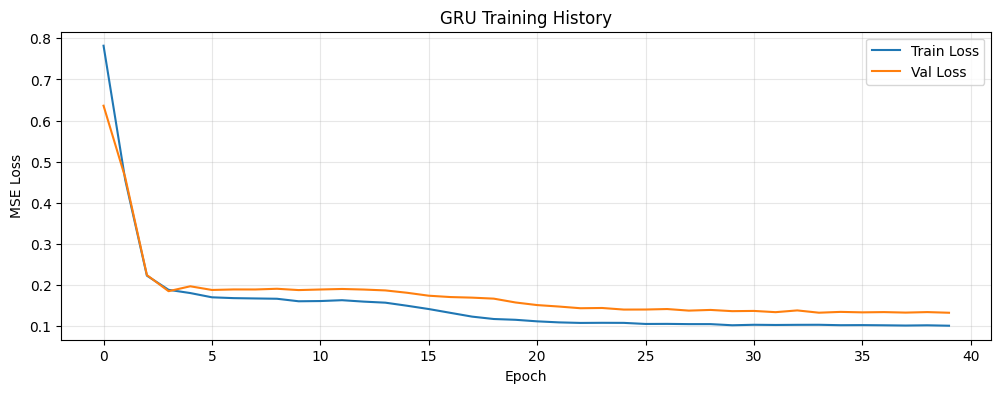

In [96]:
# Визуализация обучения
plt.figure(figsize=(12, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('GRU Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [97]:
# Определяем лучшую модель по MAE на валидации
models_performance = {
    'B1 (naive-last)': val_metrics_b1,
    'B2 (moving-average)': val_metrics_b2,
    'B3 (ridge-lag-features)': val_metrics_b3,
    'R1 (GRU)': val_metrics_r1
}

best_model_name = min(models_performance.items(), key=lambda x: x[1]['MAE'])[0]
best_val_mae = models_performance[best_model_name]['MAE']

print(f"\nЛучшая модель на валидации: {best_model_name}")
print(f"Лучшее значение MAE на валидации: {best_val_mae:.4f}")

# Собираем все результаты в DataFrame
runs_data = []

features_summary=""

# Добавляем результаты всех экспериментов
experiments = [
    ('B1 (naive-last)', val_metrics_b1, test_metrics_b1),
    ('B2 (moving-average)', val_metrics_b2, test_metrics_b2),
    ('B3 (ridge-lag-features)', val_metrics_b3, test_metrics_b3),
    ('R1 (GRU)', val_metrics_r1, test_metrics_r1)
]

for exp_name, val_metrics, test_metrics in experiments:
    runs_data.append({
    'experiment_id': f"R1_{seed}",
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': seed,
    'split_summary': 'temporal_split_70-15-15',
    'window_size': window_size,
    'horizon': horizon,
    'model_summary': str(model),
    'features_summary': features_summary,
    'scaler': 'StandardScaler(target)',
    'optimizer': 'Adam',
    'lr': lr,
    'epochs_trained': epochs,
    'best_val_mae': val_metrics['MAE'],
    'best_val_rmse': val_metrics['RMSE'],
    'best_val_mape': val_metrics['MAPE'],
    'test_mae': test_metrics['MAE'],
    'test_rmse': test_metrics['RMSE'],
    'test_mape': test_metrics['MAPE'],
    'notes': 'GRU with early stopping, best on validation',
    'best_model_on_val': exp_name == best_model_name
})

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)

print(runs_df.to_string(index=False))

print(f"\nСравнение моделей на валидации (метрика: MAE):")
for exp_name, metrics in models_performance.items():
    print(f"  {exp_name:25s}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, MAPE={metrics['MAPE']:.2f}%")

print(f"\nЛучшая модель: {best_model_name} (MAE={best_val_mae:.4f})")
print(f"Результаты лучшей модели на тесте:")
best_test_metrics = models_performance[best_model_name]  # нужно получить из runs_data
for exp_name, _, test_metrics in experiments:
    if exp_name == best_model_name:
        print(f"  MAE={test_metrics['MAE']:.4f}, RMSE={test_metrics['RMSE']:.4f}, MAPE={test_metrics['MAPE']:.2f}%")


Лучшая модель на валидации: B3 (ridge-lag-features)
Лучшее значение MAE на валидации: 4.0461
experiment_id        task        dataset  seed           split_summary  window_size  horizon                                                                                                                                model_summary features_summary                 scaler optimizer    lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape                                       notes  best_model_on_val
        R1_42 forecasting S12-hw-dataset    42 temporal_split_70-15-15           28        1 GRUForecast(\n  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)\n  (fc): Linear(in_features=64, out_features=1, bias=True)\n)                  StandardScaler(target)      Adam 0.001              40      6.454645       8.239124       4.400688  6.366645   8.107879   4.168898 GRU with early stopping, best on validation              False
        R1_42 fo

In [98]:
torch.save(model.state_dict(), 'artifacts/best_gru.pt')

In [ ]:
def make_run_row(
    experiment_id: str,
    val_metrics: dict = None,
    test_metrics: dict = None,
    window_size: int = 28,
    horizon: int = 1,
    model_summary: str = "",
    features_summary: str = "",
    scaler: str = "",
    optimizer: str = None,
    lr: float = None,
    epochs_trained: int = None,
    notes: str = "",
    **kwargs
):

    # Базовые параметры, общие для всех экспериментов
    row = {
        'experiment_id': experiment_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal_split_70-15-15',
        'window_size': window_size,
        'horizon': horizon,
        'model_summary': model_summary,
        'features_summary': features_summary,
        'scaler': scaler,
        'optimizer': optimizer,
        'lr': lr,
        'epochs_trained': epochs_trained,
        'best_val_mae': val_metrics.get('MAE') if val_metrics else None,
        'best_val_rmse': val_metrics.get('RMSE') if val_metrics else None,
        'best_val_mape': val_metrics.get('MAPE') if val_metrics else None,
        'test_mae': test_metrics.get('MAE') if test_metrics else None,
        'test_rmse': test_metrics.get('RMSE') if test_metrics else None,
        'test_mape': test_metrics.get('MAPE') if test_metrics else None,
        'notes': notes,
        **kwargs
    }
    return row

# Собираем результаты
rows = []

# B1: Naive last
rows.append(
    make_run_row(
        experiment_id="B1",
        val_metrics=val_metrics_b1,
        test_metrics=test_metrics_b1,
        model_summary="naive_last",
        features_summary="no features",
        scaler="none",
        notes="Baseline: predict last observed value"
    )
)

# B2: Moving average (лучшее окно 3)
rows.append(
    make_run_row(
        experiment_id="B2",
        val_metrics=val_metrics_b2,
        test_metrics=test_metrics_b2,
        model_summary="moving_average(window=3)",
        features_summary="no features",
        scaler="none",
        notes="Baseline: rolling mean, window=3 (best on validation)"
    )
)

# B3: Ridge regression
rows.append(
    make_run_row(
        experiment_id="B3",
        val_metrics=val_metrics_b3,
        test_metrics=test_metrics_b3,
        model_summary="Ridge(alpha=1.0)",
        features_summary="lags(1-42) + rolling_stats(3,7,14,28) + ewm(0.3,0.1) + diff(1,7,28) + calendar_features",
        scaler="StandardScaler(features)",
        notes="Best model on validation and test"
    )
)

# R1: GRU
hidden_size = 64
num_layers = 2
lr = 0.001

rows.append(
    make_run_row(
        experiment_id="R1",
        val_metrics=val_metrics_r1,
        test_metrics=test_metrics_r1,
        window_size=window_size,
        model_summary=f"GRU(hidden_size={hidden_size}, num_layers={num_layers}, dropout=0.2)",
        features_summary="scaled target windows (28 timesteps)",
        scaler="StandardScaler(target)",
        optimizer="Adam",
        lr=lr,
        epochs_trained=len(history['train_loss']),
        notes="GRU with early stopping, best on validation"
    )
)

# Создаём DataFrame и сохраняем
runs_df = pd.DataFrame(rows)
runs_df.to_csv('artifacts/runs.csv', index=False)

print("\nРезультаты:")
print(runs_df.to_string(index=False))


Результаты:
experiment_id        task        dataset  seed           split_summary  window_size  horizon                                  model_summary                                                                        features_summary                   scaler optimizer    lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape                                                 notes
           B1 forecasting S12-hw-dataset    42 temporal_split_70-15-15           28        1                                     naive_last                                                                             no features                     none      None   NaN             NaN      6.454645       8.239124       4.400688  6.366645   8.107879   4.168898                 Baseline: predict last observed value
           B2 forecasting S12-hw-dataset    42 temporal_split_70-15-15           28        1                       moving_average(window=3)                  

In [100]:
import json
import os

# Создаем директорию artifacts, если её нет
os.makedirs('artifacts', exist_ok=True)

# Функция для преобразования numpy типов в Python типы
def convert_to_serializable(obj):
    """Рекурсивно преобразует numpy типы в стандартные Python типы"""
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

# Конфигурация лучшей GRU модели
best_gru_config = {
    "model_type": "GRU",
    "window_size": int(window_size),  # преобразуем в int
    "hidden_size": int(hidden_size),  # преобразуем в int
    "num_layers": int(num_layers),    # преобразуем в int
    "dropout": float(0.2),        # преобразуем в float
    "input_size": 1,
    "output_size": 1,
    "batch_size": int(batch_size),    # преобразуем в int
    "lr": float(lr),                  # преобразуем в float
    "epochs_trained": int(len(history['train_loss'])),  # преобразуем в int
    "epochs_max": epochs,
    "seed": 42,
    "scaler": "StandardScaler(target)",
    "optimizer": "Adam",
    "loss_function": "MSELoss",
    "device": str(device),
    # Преобразуем метрики в float
    "best_val_mae": float(val_metrics_r1['MAE']),
    "best_val_rmse": float(val_metrics_r1['RMSE']),
    "best_val_mape": float(val_metrics_r1['MAPE']),
    "test_mae": float(test_metrics_r1['MAE']),
    "test_rmse": float(test_metrics_r1['RMSE']),
    "test_mape": float(test_metrics_r1['MAPE']),
    "split_summary": "temporal_split_70-15-15",
    "dataset": "S12-hw-dataset",
    "notes": "GRU with early stopping, best on validation, slightly overfitted on test"
}

# Дополнительная защита: преобразуем все значения рекурсивно
best_gru_config = convert_to_serializable(best_gru_config)

# Сохраняем конфиг в JSON
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(best_gru_config, f, indent=2)

print("\nСодержимое конфига:")
print(json.dumps(best_gru_config, indent=2))


Содержимое конфига:
{
  "model_type": "GRU",
  "window_size": 28,
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.2,
  "input_size": 1,
  "output_size": 1,
  "batch_size": 128,
  "lr": 0.001,
  "epochs_trained": 40,
  "epochs_max": 40,
  "seed": 42,
  "scaler": "StandardScaler(target)",
  "optimizer": "Adam",
  "loss_function": "MSELoss",
  "device": "cpu",
  "best_val_mae": 5.182623863220215,
  "best_val_rmse": 6.715835577928157,
  "best_val_mape": 3.47635555267334,
  "test_mae": 5.9391889572143555,
  "test_rmse": 7.554766523387761,
  "test_mape": 3.7925832271575928,
  "split_summary": "temporal_split_70-15-15",
  "dataset": "S12-hw-dataset",
  "notes": "GRU with early stopping, best on validation, slightly overfitted on test"
}


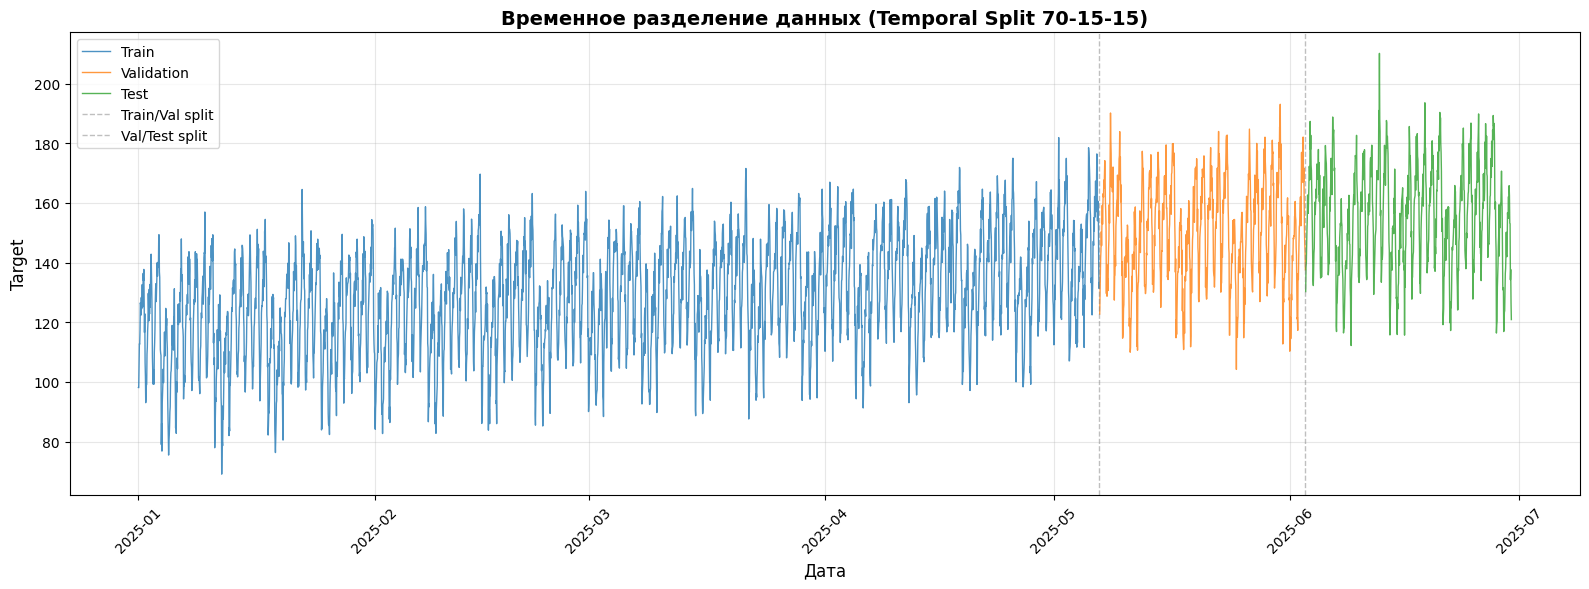

Сохранено: figures/series_split.png


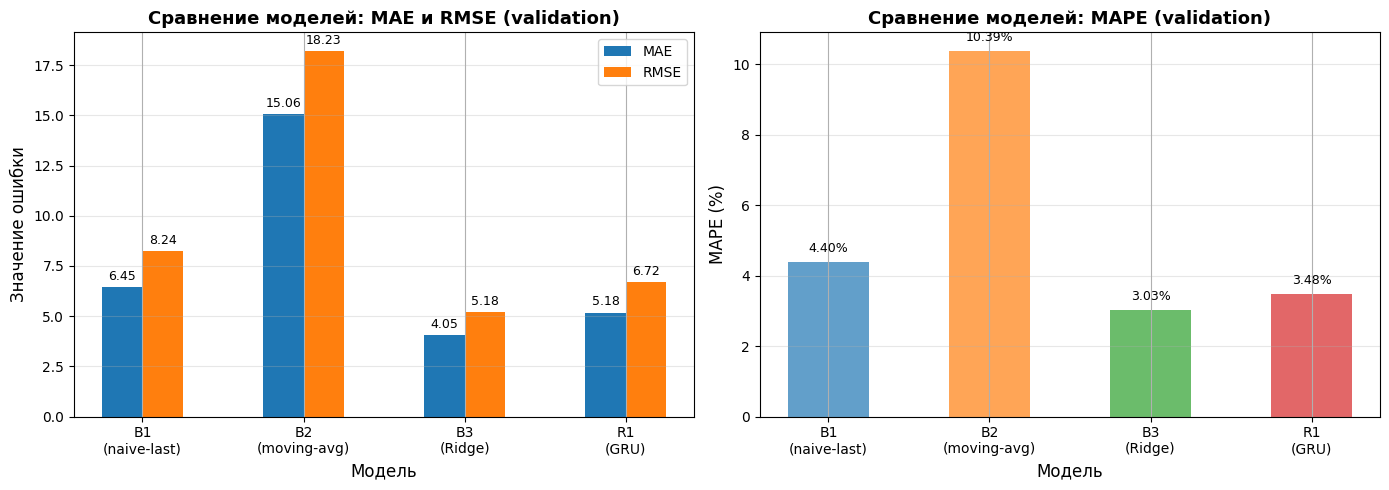

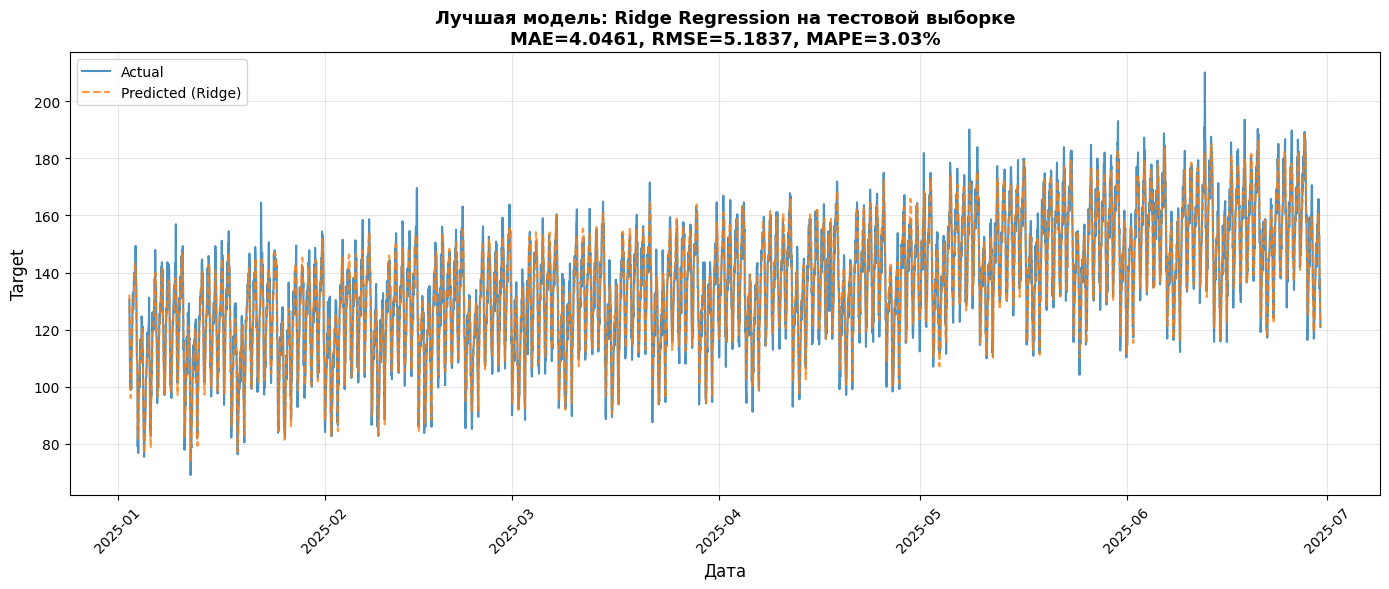

In [101]:
plt.figure(figsize=(16, 6))

# Используем исходные данные после temporal split
plt.plot(train_df['date'], train_df['target'],
         label='Train', color='#1f77b4', linewidth=1, alpha=0.8)
plt.plot(val_df['date'], val_df['target'],
         label='Validation', color='#ff7f0e', linewidth=1, alpha=0.8)
plt.plot(test_df['date'], test_df['target'],
         label='Test', color='#2ca02c', linewidth=1, alpha=0.8)

# Вертикальные линии на границах разбиения
plt.axvline(x=train_df['date'].max(), color='gray',
            linestyle='--', linewidth=1, alpha=0.5, label='Train/Val split')
plt.axvline(x=val_df['date'].max(), color='gray',
            linestyle='--', linewidth=1, alpha=0.5, label='Val/Test split')

plt.title('Временное разделение данных (Temporal Split 70-15-15)',
          fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=300, bbox_inches='tight')
plt.show()
print("Сохранено: figures/series_split.png")



models = ['B1\n(naive-last)', 'B2\n(moving-avg)', 'B3\n(Ridge)', 'R1\n(GRU)']
mae_values = [val_metrics_b1['MAE'], val_metrics_b2['MAE'],
              val_metrics_b3['MAE'], val_metrics_r1['MAE']]
rmse_values = [val_metrics_b1['RMSE'], val_metrics_b2['RMSE'],
               val_metrics_b3['RMSE'], val_metrics_r1['RMSE']]
mape_values = [val_metrics_b1['MAPE'], val_metrics_b2['MAPE'],
               val_metrics_b3['MAPE'], val_metrics_r1['MAPE']]

x = np.arange(len(models))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График MAE и RMSE
bars1 = ax1.bar(x - width/2, mae_values, width, label='MAE', color='#1f77b4')
bars2 = ax1.bar(x + width/2, rmse_values, width, label='RMSE', color='#ff7f0e')
ax1.set_xlabel('Модель', fontsize=12)
ax1.set_ylabel('Значение ошибки', fontsize=12)
ax1.set_title('Сравнение моделей: MAE и RMSE (validation)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars, values in [(bars1, mae_values), (bars2, rmse_values)]:
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# График MAPE
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars3 = ax2.bar(x, mape_values, width*2, color=colors, alpha=0.7)
ax2.set_xlabel('Модель', fontsize=12)
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_title('Сравнение моделей: MAPE (validation)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, val in zip(bars3, mape_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()



y_test_actual = y_test_b3
y_test_pred = y_pred_test_b3

test_dates = test_features['date'].values

plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test_actual,
         label='Actual', color='#1f77b4', linewidth=1.5, alpha=0.8)
plt.plot(test_dates, y_test_pred,
         label='Predicted (Ridge)', color='#ff7f0e', linewidth=1.5, alpha=0.8, linestyle='--')

plt.title(f'Лучшая модель: Ridge Regression на тестовой выборке\n'
          f'MAE={test_metrics_b3["MAE"]:.4f}, RMSE={test_metrics_b3["RMSE"]:.4f}, MAPE={test_metrics_b3["MAPE"]:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=300, bbox_inches='tight')
plt.show()

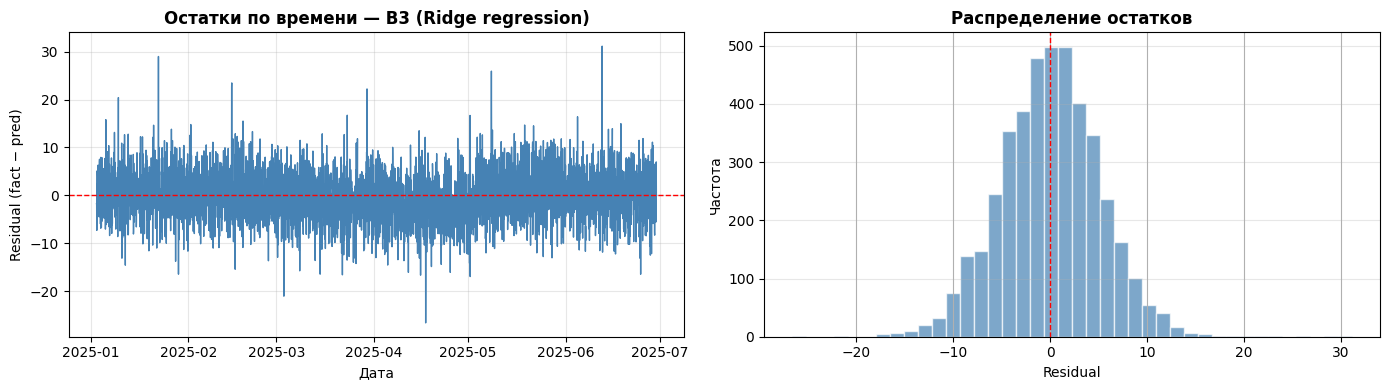


Статистика остатков (B3 (Ridge regression)):
Среднее остатков: -0.0000
Std остатков:     5.1837


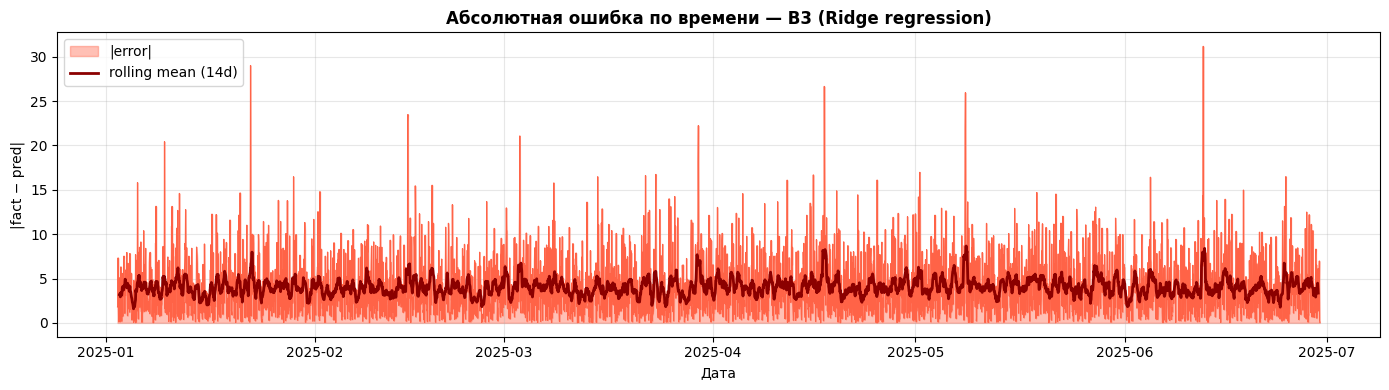

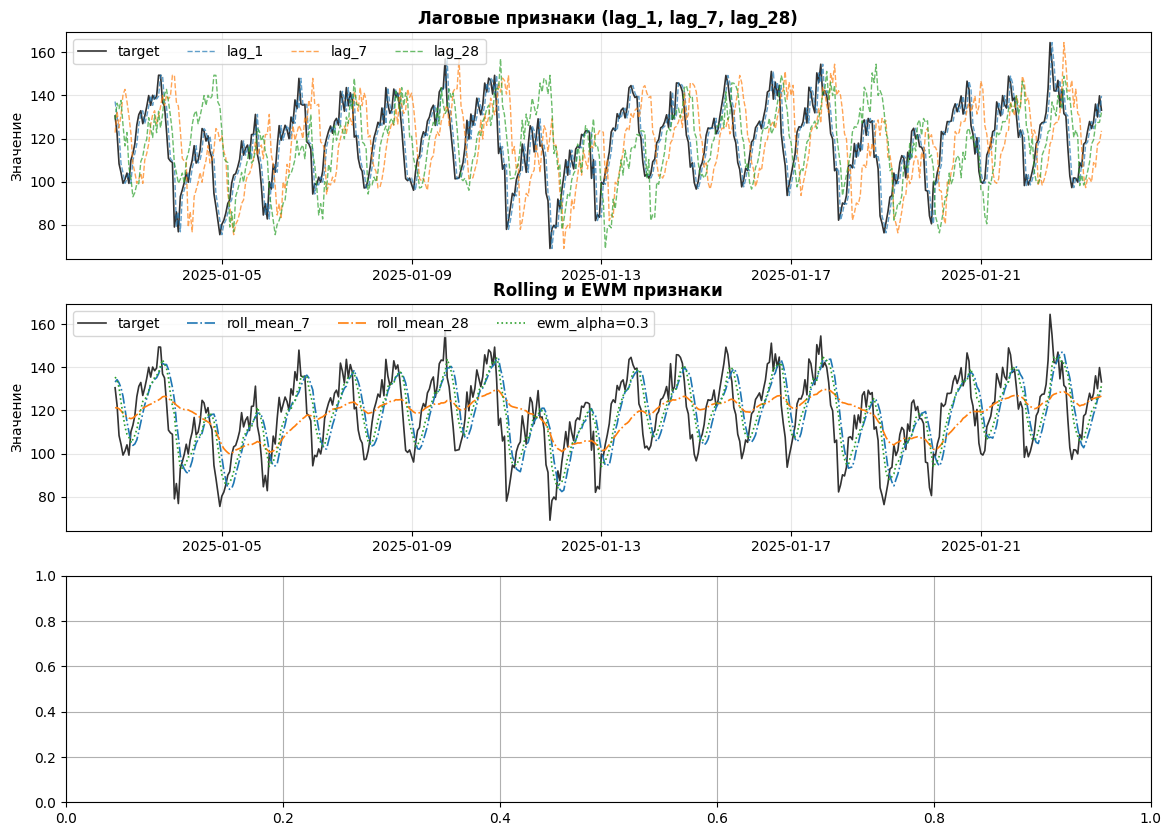

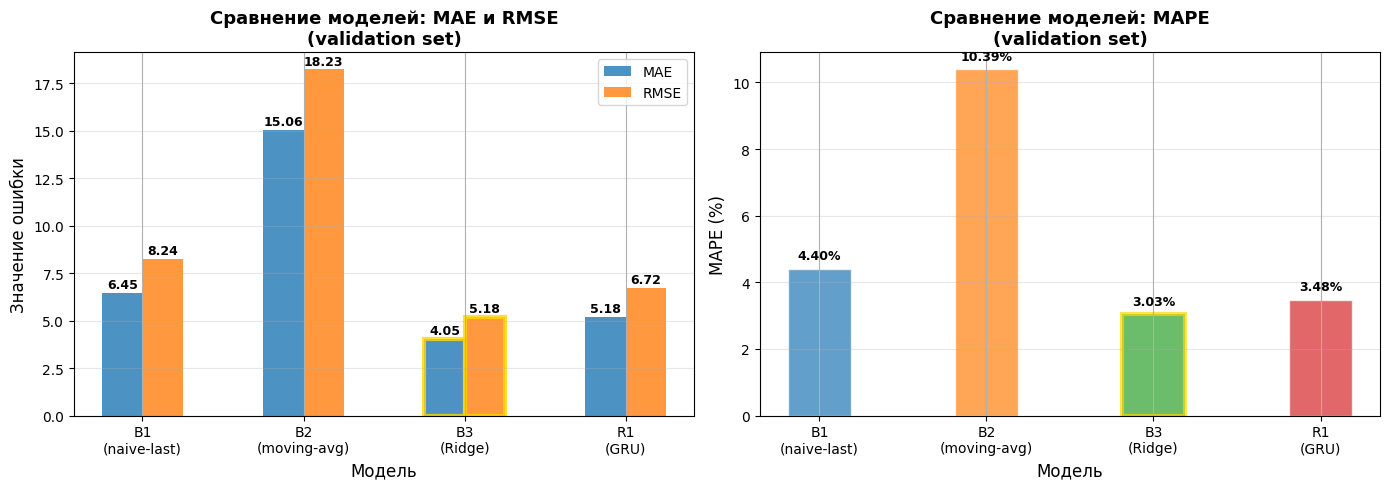

In [102]:
best_model_name = "B3 (Ridge regression)"
best_test_true = y_test_b3  # фактические значения
best_test_pred = y_pred_test_b3  # предсказанные значения
best_test_dates = test_features['date'].values  # даты

# Остатки
residuals = best_test_true - best_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_test_dates, residuals, color="steelblue", linewidth=1.0)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.0)
axes[0].set_title(f"Остатки по времени — {best_model_name}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Дата", fontsize=10)
axes[0].set_ylabel("Residual (fact − pred)", fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.0)
axes[1].set_title("Распределение остатков", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Residual", fontsize=10)
axes[1].set_ylabel("Частота", fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nСтатистика остатков ({best_model_name}):")
print(f"Среднее остатков: {residuals.mean():.4f}")
print(f"Std остатков:     {residuals.std():.4f}")


abs_errors = np.abs(residuals)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(best_test_dates, abs_errors, alpha=0.4, color="tomato", label="|error|")
ax.plot(best_test_dates, abs_errors, color="tomato", linewidth=0.8)

# Скользящее среднее ошибки для читаемости
window_err = min(14, len(abs_errors) // 4)
rolling_err = pd.Series(abs_errors).rolling(window_err, center=True).mean()
ax.plot(best_test_dates, rolling_err, color="darkred", linewidth=2.0,
        label=f"rolling mean ({window_err}d)")

ax.set_title(f"Абсолютная ошибка по времени — {best_model_name}", fontsize=12, fontweight='bold')
ax.set_xlabel("Дата", fontsize=10)
ax.set_ylabel("|fact − pred|", fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_time.png', dpi=300, bbox_inches='tight')
plt.show()


features_df = features_data.copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Берем период для лучшей визуализации (первые 500 точек после удаления NaN)
sample_start = 0
sample_end = min(500, len(features_df))
sample_dates = features_df["date"].iloc[sample_start:sample_end]

# 1. Лаги
axes[0].plot(sample_dates, features_df["target"].iloc[sample_start:sample_end],
             label="target", linewidth=1.2, alpha=0.8, color='black')
axes[0].plot(sample_dates, features_df["lag_1"].iloc[sample_start:sample_end],
             label="lag_1", linewidth=1.0, linestyle="--", alpha=0.7)
axes[0].plot(sample_dates, features_df["lag_7"].iloc[sample_start:sample_end],
             label="lag_7", linewidth=1.0, linestyle="--", alpha=0.7)
axes[0].plot(sample_dates, features_df["lag_28"].iloc[sample_start:sample_end],
             label="lag_28", linewidth=1.0, linestyle="--", alpha=0.7)
axes[0].set_title("Лаговые признаки (lag_1, lag_7, lag_28)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Значение", fontsize=10)
axes[0].legend(ncol=4)
axes[0].grid(True, alpha=0.3)

# 2. Rolling-средние
axes[1].plot(sample_dates, features_df["target"].iloc[sample_start:sample_end],
             label="target", linewidth=1.2, alpha=0.8, color='black')
axes[1].plot(sample_dates, features_df["roll_mean_7"].iloc[sample_start:sample_end],
             label="roll_mean_7", linewidth=1.2, linestyle="-.")
axes[1].plot(sample_dates, features_df["roll_mean_28"].iloc[sample_start:sample_end],
             label="roll_mean_28", linewidth=1.2, linestyle="-.")
axes[1].plot(sample_dates, features_df["ewm_3"].iloc[sample_start:sample_end],
             label="ewm_alpha=0.3", linewidth=1.2, linestyle=":")
axes[1].set_title("Rolling и EWM признаки", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Значение", fontsize=10)
axes[1].legend(ncol=4)
axes[1].grid(True, alpha=0.3)
models = ['B1\n(naive-last)', 'B2\n(moving-avg)', 'B3\n(Ridge)', 'R1\n(GRU)']
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Метрики на валидации
mae_values = [val_metrics_b1['MAE'], val_metrics_b2['MAE'],
              val_metrics_b3['MAE'], val_metrics_r1['MAE']]
rmse_values = [val_metrics_b1['RMSE'], val_metrics_b2['RMSE'],
               val_metrics_b3['RMSE'], val_metrics_r1['RMSE']]
mape_values = [val_metrics_b1['MAPE'], val_metrics_b2['MAPE'],
               val_metrics_b3['MAPE'], val_metrics_r1['MAPE']]

x = np.arange(len(models))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(x - width/2, mae_values, width, label='MAE', color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x + width/2, rmse_values, width, label='RMSE', color='#ff7f0e', alpha=0.8)

ax1.set_xlabel('Модель', fontsize=12)
ax1.set_ylabel('Значение ошибки', fontsize=12)
ax1.set_title('Сравнение моделей: MAE и RMSE\n(validation set)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы (MAE)
for bar, val in zip(bars1, mae_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Добавляем значения на столбцы (RMSE)
for bar, val in zip(bars2, rmse_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars3 = ax2.bar(x, mape_values, width*1.5, color=model_colors, alpha=0.7, edgecolor='white', linewidth=1)

ax2.set_xlabel('Модель', fontsize=12)
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_title('Сравнение моделей: MAPE\n(validation set)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, val in zip(bars3, mape_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Подсвечиваем лучшую модель (B3)
for bars in [bars1, bars2, bars3]:
    bars[2].set_edgecolor('gold')
    bars[2].set_linewidth(3)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()